# Merge and Export Machine Learning Dataset - Viladecans
This notebook gathers all pre-calculated features (OSM POIs, Land Use, Momepy) and merges them into one comprehensive `.csv` table for the Viladecans ML models.

## Note: Data Requirements

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt

print("Libraries imported.")

Libraries imported.


## Load the datasets

In [2]:
path_osm_roads    = "data/osm_roads_noise_class.csv"
path_momepy_roads = "data/momepy_roads_features.csv"
path_osm_points   = "data/osm_points_features.csv"
path_osmlanduse   = "data/osm_landuse_features.csv"

df_osm_roads    = pd.read_csv(path_osm_roads)
df_momepy_roads = pd.read_csv(path_momepy_roads)
df_osm_points   = pd.read_csv(path_osm_points)
df_osm_landuse  = pd.read_csv(path_osmlanduse)

print("Data loaded successfully.")

Data loaded successfully.


In [3]:
df_osm_roads.head()

,road_id,noise_day,noise_evening,noise_night,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street
0,206378333_6315715548_0,3,3,3,5,3839.18702,3424.528320,908.189757,308.544649,0.000000,739.567769
1,208568922_208568921_0,4,3,3,1,0.00000,1715.616495,201.962356,260.579228,3533.239480,4788.496962
2,208568926_208568922_1,4,3,3,1,0.00000,1942.730762,423.807844,481.776171,3567.859601,4886.590827
3,208595138_208595144_0,4,3,3,1,0.00000,1083.830848,0.000000,23.845543,3277.375622,4349.185919
4,208595144_2332249073_0,4,3,3,1,0.00000,1616.526409,128.871293,181.058161,3498.025602,4726.558683


In [4]:
# Drop non-ML columns from momepy (openness and height are morphological intermediates)
df_momepy_roads.drop(['openness', 'height'], axis=1, inplace=True)
df_momepy_roads.head()

,road_id,width,betweenness,closeness_global,closeness400,straightness
0,206378333_6315715548_0,35.176945,0.002059,0.000324,0.000058,0.885094
1,6315715548_206378333_0,35.402010,0.002059,0.000324,0.000058,0.885094
2,2383446335_206378333_0,34.320234,0.000046,0.000313,0.000060,0.922985
3,4469422084_6315715548_0,50.000000,0.008186,0.000344,0.000080,0.873438
4,6315715548_2383446364_0,37.381258,0.004087,0.000330,0.000083,0.886747


In [5]:
df_osm_points.head()

,road_id,signals,transport,pois
0,206378333_6315715548_0,0.0,0.000000,0.0
1,208568922_208568921_0,0.0,0.000000,0.0
2,208568926_208568922_1,0.0,0.005296,0.0
3,208595138_208595144_0,0.0,0.000000,0.0
4,208595144_2332249073_0,0.0,0.000000,0.0


In [6]:
df_osm_landuse.head()

,road_id,green,industrial,commercial
0,206378333_6315715548_0,0.000000,64.460544,0.0
1,208568922_208568921_0,0.147571,0.000000,0.0
2,208568926_208568922_1,15.415345,0.000000,0.0
3,208595138_208595144_0,9.872402,0.000000,0.0
4,208595144_2332249073_0,6.551946,0.000000,0.0


## Merge dataframes

In [7]:
def merge_feature_dataframe(base_df, feature_df, cols_to_drop):
    clean_df = feature_df.drop(columns=[c for c in cols_to_drop if c in feature_df.columns], errors='ignore')
    cols_to_remove = [c for c in clean_df.columns if c in base_df.columns and c != 'road_id']
    clean_df = clean_df.drop(columns=cols_to_remove, errors='ignore')
    if 'road_id' not in clean_df.columns or 'road_id' not in base_df.columns:
        return base_df
    clean_df['road_id'] = clean_df['road_id'].astype(str)
    base_df = base_df.copy()
    base_df['road_id'] = base_df['road_id'].astype(str)
    return base_df.merge(clean_df, on='road_id', how='left')

In [8]:
ml_dataset = df_osm_roads.copy()
cols_to_drop = ['noise_day', 'noise_evening', 'noise_night']

print("Road ID types:")
print(f"ml_dataset: {ml_dataset['road_id'].dtype}")

for name, df in [
    ('OSM Points',   df_osm_points),
    ('Momepy Roads', df_momepy_roads),
    ('OSM Landuse',  df_osm_landuse),
]:
    if 'road_id' in df.columns:
        print(f"{name}: {df['road_id'].dtype}")
    else:
        print(f"{name}: NO road_id column!")
    ml_dataset = merge_feature_dataframe(ml_dataset, df, cols_to_drop)

ml_dataset = ml_dataset.fillna(0)

display(ml_dataset.head(10))
ml_dataset.info()
print(f"Final dataset shape: {ml_dataset.shape}")

Road ID types:
ml_dataset: str
OSM Points: str
Momepy Roads: str
OSM Landuse: str


,road_id,noise_day,noise_evening,noise_night,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,...,transport,pois,width,betweenness,closeness_global,closeness400,straightness,green,industrial,commercial
0,206378333_6315715548_0,3,3,3,5,3839.187020,3424.528320,908.189757,308.544649,0.000000,...,0.000000,0.0,35.176945,0.002059,0.000324,0.000058,0.885094,0.000000,64.460544,0.0
1,208568922_208568921_0,4,3,3,1,0.000000,1715.616495,201.962356,260.579228,3533.239480,...,0.000000,0.0,50.000000,0.000005,0.000008,0.000007,0.998369,0.147571,0.000000,0.0
2,208568926_208568922_1,4,3,3,1,0.000000,1942.730762,423.807844,481.776171,3567.859601,...,0.005296,0.0,50.000000,0.000005,0.000009,0.000008,0.998353,15.415345,0.000000,0.0
3,208595138_208595144_0,4,3,3,1,0.000000,1083.830848,0.000000,23.845543,3277.375622,...,0.000000,0.0,50.000000,0.000012,0.000007,0.000000,0.497292,9.872402,0.000000,0.0
4,208595144_2332249073_0,4,3,3,1,0.000000,1616.526409,128.871293,181.058161,3498.025602,...,0.000000,0.0,50.000000,0.000018,0.000010,0.000007,0.996023,6.551946,0.000000,0.0
5,211305820_211305823_0,3,3,2,4,4324.460415,3933.108152,1345.330742,0.000000,24.647020,...,0.000000,0.0,36.620447,0.002105,0.000501,0.000116,0.884973,3.768869,18.960028,0.0
6,211305823_1564374009_0,3,3,3,4,4327.284307,3933.697404,1341.378846,0.000000,31.251669,...,0.000000,0.0,50.000000,0.004039,0.000505,0.000124,0.915521,5.746273,24.467272,0.0
7,211305823_211305824_0,3,3,3,4,4327.284307,3933.802237,1345.330742,0.000000,29.093975,...,0.000000,0.0,50.000000,0.000166,0.000504,0.000123,0.907644,6.991218,21.223239,0.0
8,211305824_211305825_0,3,3,2,4,4337.636048,3942.312125,1349.793254,0.000000,7.032176,...,0.000000,0.0,50.000000,0.008485,0.000501,0.000119,0.887011,7.092477,13.908829,0.0
9,211305825_1131453368_0,3,3,3,4,4350.846617,3960.937454,1372.706561,0.000000,0.000000,...,0.000000,0.0,50.000000,0.006642,0.000498,0.000113,0.864779,5.877630,3.562328,0.0


<class 'pandas.DataFrame'>
RangeIndex: 1613 entries, 0 to 1612
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   road_id                1613 non-null   str    
 1   noise_day              1613 non-null   int64  
 2   noise_evening          1613 non-null   int64  
 3   noise_night            1613 non-null   int64  
 4   road_category          1613 non-null   int64  
 5   dist_to_trunk          1613 non-null   float64
 6   dist_to_primary        1613 non-null   float64
 7   dist_to_secondary      1613 non-null   float64
 8   dist_to_tertiary       1613 non-null   float64
 9   dist_to_residential    1613 non-null   float64
 10  dist_to_living_street  1613 non-null   float64
 11  signals                1613 non-null   float64
 12  transport              1613 non-null   float64
 13  pois                   1613 non-null   float64
 14  width                  1613 non-null   float64
 15  betweenness    

## Noise distribution

     Day  Evening  Night
0    NaN      NaN  154.0
1  154.0    324.0  575.0
2  686.0    808.0  620.0
3  603.0    438.0  264.0
4  170.0     43.0    NaN


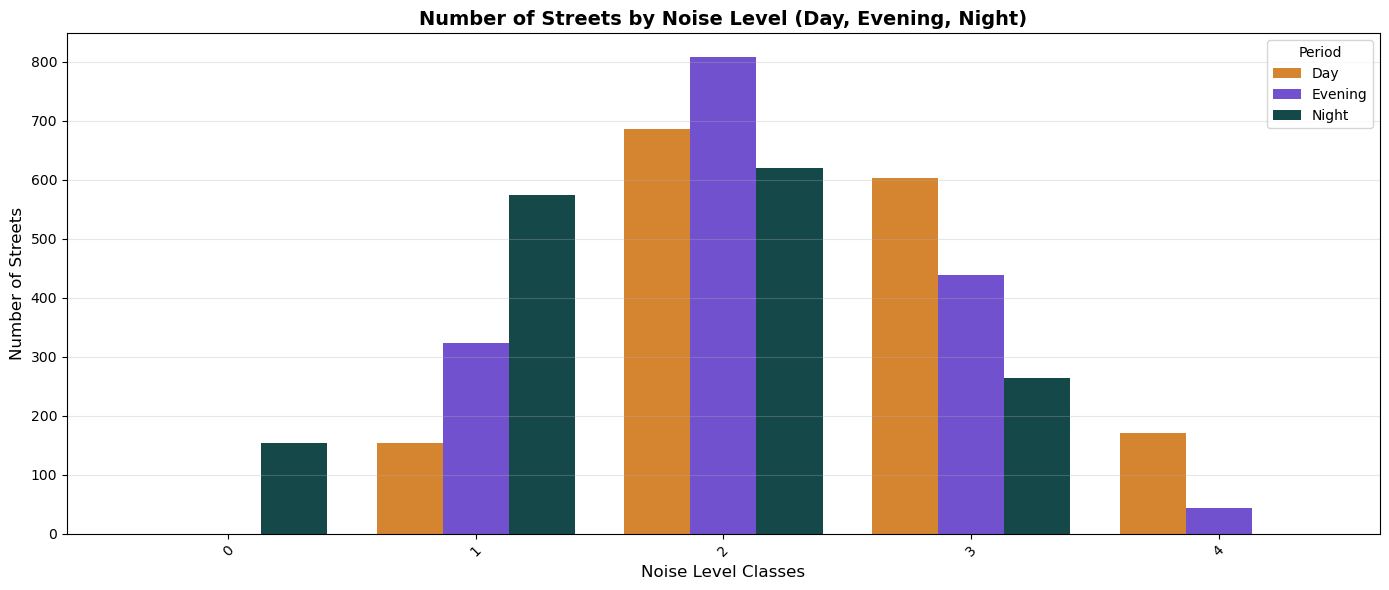

In [9]:
fig, ax = plt.subplots(figsize=(14, 6))

counts_day     = ml_dataset.groupby('noise_day').size()
counts_evening = ml_dataset.groupby('noise_evening').size()
counts_night   = ml_dataset.groupby('noise_night').size()

comparison_df = pd.DataFrame({'Day': counts_day, 'Evening': counts_evening, 'Night': counts_night})

print(comparison_df)
comparison_df[['Day', 'Evening', 'Night']].plot(
    kind='bar', ax=ax, width=0.8, color=['#d58430', '#7251ce', '#144849'])
ax.set_title('Number of Streets by Noise Level (Day, Evening, Night)', fontsize=14, fontweight='bold')
ax.set_xlabel('Noise Level Classes', fontsize=12)
ax.set_ylabel('Number of Streets', fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Period')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Export to CSV
Final master table for scikit-learn in the next phase.

In [10]:
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)

final_path = os.path.join(output_dir, "vil_noise_class_ml_dataset.csv")
ml_dataset.to_csv(final_path, index=False)

print(f"Dataset successfully exported to: {final_path}")

Dataset successfully exported to: data\vil_noise_class_ml_dataset.csv


## Subsample
Stratified subsample of 5000 segments preserving noise_day class distribution.

In [11]:
# Viladecans is small: cap the subsample at the dataset size
sample_size = min(5000, len(ml_dataset))

proportions = ml_dataset['noise_day'].value_counts(normalize=True).sort_index()
samples_per_value = (proportions * sample_size).round().astype(int)

subsampled = pd.concat([
    ml_dataset[ml_dataset['noise_day'] == val].sample(n=n, random_state=42, replace=False)
    for val, n in samples_per_value.items() if n > 0
])

subsampled = subsampled.sample(frac=1, random_state=42).reset_index(drop=True)

print(subsampled['noise_day'].value_counts(normalize=True).sort_index())

noise_day
1    0.095474
2    0.425294
3    0.373838
4    0.105394
Name: proportion, dtype: float64


## Before and after sampling

           Before  After
noise_day               
1             154    154
2             686    686
3             603    603
4             170    170


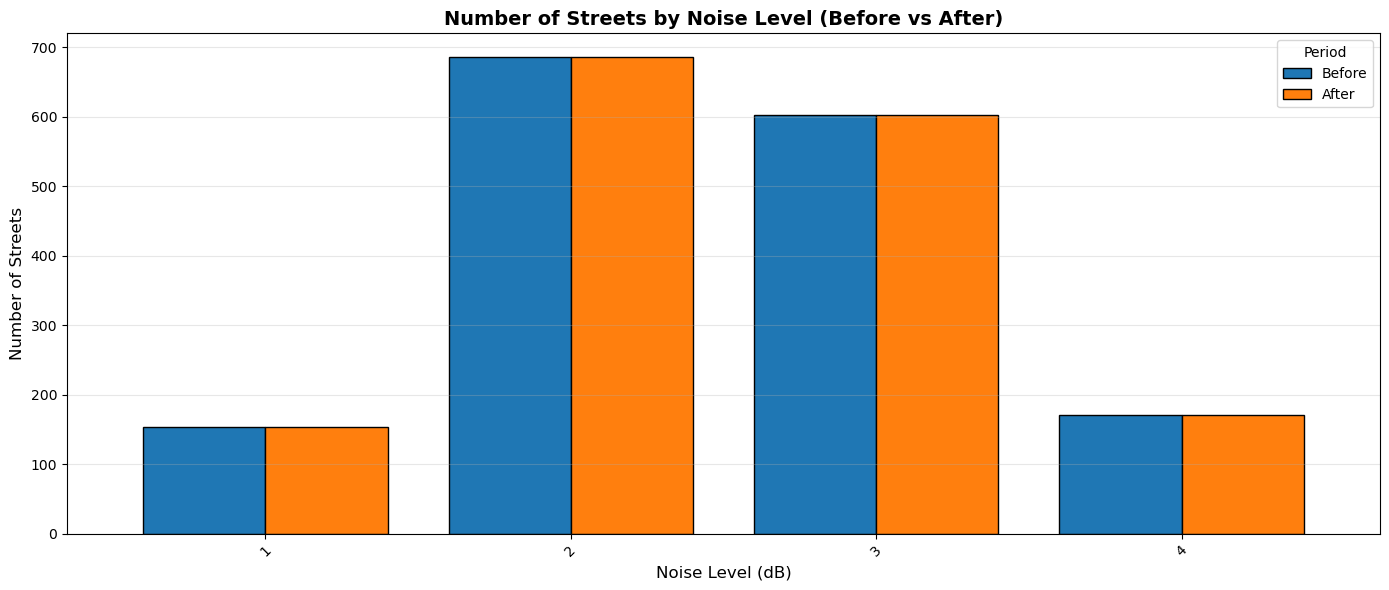

In [12]:
fig, ax = plt.subplots(figsize=(14, 6))

counts_before = ml_dataset.groupby('noise_day').size()
counts_after  = subsampled.groupby('noise_day').size()

comparison_df = pd.DataFrame({'Before': counts_before, 'After': counts_after})

print(comparison_df)
comparison_df[['Before', 'After']].plot(kind='bar', ax=ax, edgecolor='black', width=0.8)
ax.set_title('Number of Streets by Noise Level (Before vs After)', fontsize=14, fontweight='bold')
ax.set_xlabel('Noise Level (dB)', fontsize=12)
ax.set_ylabel('Number of Streets', fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Period')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Export CSV

In [13]:
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)

final_path = os.path.join(output_dir, "vil_noise_class_ml_subsample.csv")
subsampled.to_csv(final_path, index=False)

print(f"Dataset successfully exported to: {final_path}")

Dataset successfully exported to: data\vil_noise_class_ml_subsample.csv
